In [1]:
import numpy as np
import matplotlib.pyplot as plt
from NN_trial import*

In [2]:
my_NN = NN_trial(2,32)

# try training with some simple sine data (ok becasue between -1 and 1)
xx = np.linspace(0, np.pi, 50)
xx = [[x] for x in xx]
yy = [[np.sin(x[0])] for x in xx]

my_NN.train(xx,yy)

array([0.70035358])

In [3]:
epochs = 2000
losses = []

# Training loop:
for epoch in range(epochs):
    losses.append(my_NN.train(xx,yy, lr = 0.01)[0])
    if epoch%250 == 0:
        print('Epoch ', epoch, '/', epochs, ': loss = ', losses[-1])

Epoch  0 / 2000 : loss =  0.503525325280786
Epoch  250 / 2000 : loss =  0.05557677319159167
Epoch  500 / 2000 : loss =  0.02263912850523585
Epoch  750 / 2000 : loss =  0.0066395941415185325
Epoch  1000 / 2000 : loss =  0.003913417139923975
Epoch  1250 / 2000 : loss =  0.0026105011030975616
Epoch  1500 / 2000 : loss =  0.0018673420253184395
Epoch  1750 / 2000 : loss =  0.0014425278601857858


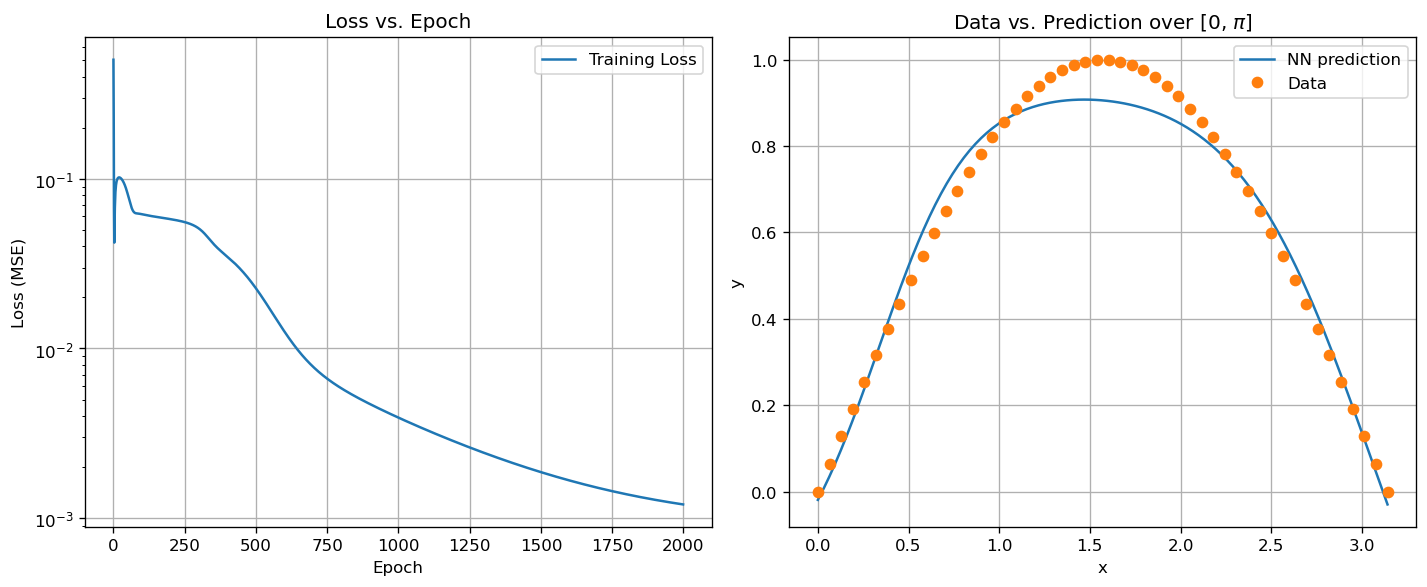

In [4]:
x_smooth = np.linspace(0, np.pi, 200)


plt.figure(figsize=(12, 5), dpi = 120)

# On the left: Loss as a function of Epoch
plt.subplot(1, 2, 1)
plt.semilogy(losses, label='Training Loss')
plt.title('Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.legend()

# On the right: Data vs. Prediction over [0, pi]
plt.subplot(1, 2, 2)
plt.plot(x_smooth, [my_NN.predict([x]) for x in x_smooth], label = "NN prediction")
plt.plot(xx, yy, 'o', label='Data')
plt.title('Data vs. Prediction over [0, $\pi$]')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

**Comments**
- for the simple example of the sin(x) data, a smaller number of layers seems to work better. Need greater number of nodes for greater training sample size.
- the optimizer is not optimized, in particular the fixed learning rate. sometimes the convergence is very good, sometimes not. Should be improved...

Epoch [100/2000], Loss: 0.0012
Epoch [200/2000], Loss: 0.0007
Epoch [300/2000], Loss: 0.0004
Epoch [400/2000], Loss: 0.0003
Epoch [500/2000], Loss: 0.0002
Epoch [600/2000], Loss: 0.0001
Epoch [700/2000], Loss: 0.0001
Epoch [800/2000], Loss: 0.0001
Epoch [900/2000], Loss: 0.0000
Epoch [1000/2000], Loss: 0.0000
Epoch [1100/2000], Loss: 0.0000
Epoch [1200/2000], Loss: 0.0000
Epoch [1300/2000], Loss: 0.0000
Epoch [1400/2000], Loss: 0.0002
Epoch [1500/2000], Loss: 0.0000
Epoch [1600/2000], Loss: 0.0000
Epoch [1700/2000], Loss: 0.0000
Epoch [1800/2000], Loss: 0.0000
Epoch [1900/2000], Loss: 0.0000
Epoch [2000/2000], Loss: 0.0000


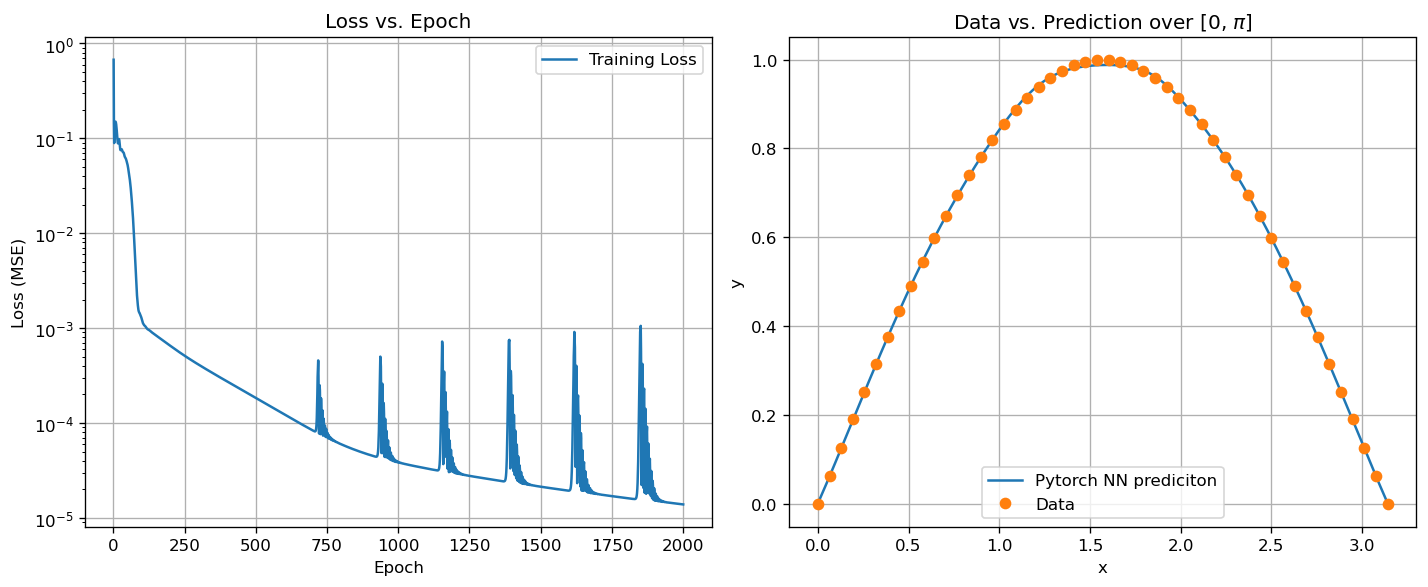

In [5]:
# now compare with PyTorch

import torch
import torch.nn as nn
import torch.optim as optim

X = torch.tensor(xx, dtype=torch.float32)
Y = torch.tensor(yy, dtype=torch.float32)

# Define a simple network with tanh activations
model = nn.Sequential(
    nn.Linear(1, 32),  
    nn.Tanh(),         
    nn.Linear(32, 32),  
    nn.Tanh(),
    nn.Linear(32, 1),  
    nn.Tanh()
)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Lists to store metrics for plotting
epochs = []
losses = []

# Training loop
num_epochs = 2000
for epoch in range(num_epochs):
    predictions = model(X)
    loss = criterion(predictions, Y)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Track loss history
    epochs.append(epoch + 1)
    losses.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# Generate predictions for the final plot
model.eval()  # Put model in evaluation mode

x_smooth_formatted = [[x] for x in x_smooth]
x_smooth_tensor = torch.tensor(x_smooth_formatted, dtype=torch.float32)
with torch.no_grad():
    final_predictions = model(x_smooth_tensor).numpy()



plt.figure(figsize=(12, 5), dpi = 120)

# On the left: Loss as a function of Epoch
plt.subplot(1, 2, 1)
plt.semilogy(epochs, losses, label='Training Loss')
plt.title('Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.legend()

# On the right: Data vs. Prediction over [0, pi]
plt.subplot(1, 2, 2)
plt.plot(x_smooth.flatten(), final_predictions.flatten(), label='Pytorch NN prediciton')
plt.plot(xx, yy, 'o', label='Data')
plt.title('Data vs. Prediction over [0, $\pi$]')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

**The PyTorch code converges much faster and gives much better results** (the individual training iterations are also faster). Possibly due do the overly rudimentary optimization procedure that I used in my code?

Note: here 2000 epochs for the PyTorch are clearly overkill. Just for comparison with my own model.
